In [117]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

import warnings
warnings.filterwarnings("ignore")

In [118]:
import numpy as np
import scienceplots 
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.ticker as ticker
from scipy.signal import argrelextrema

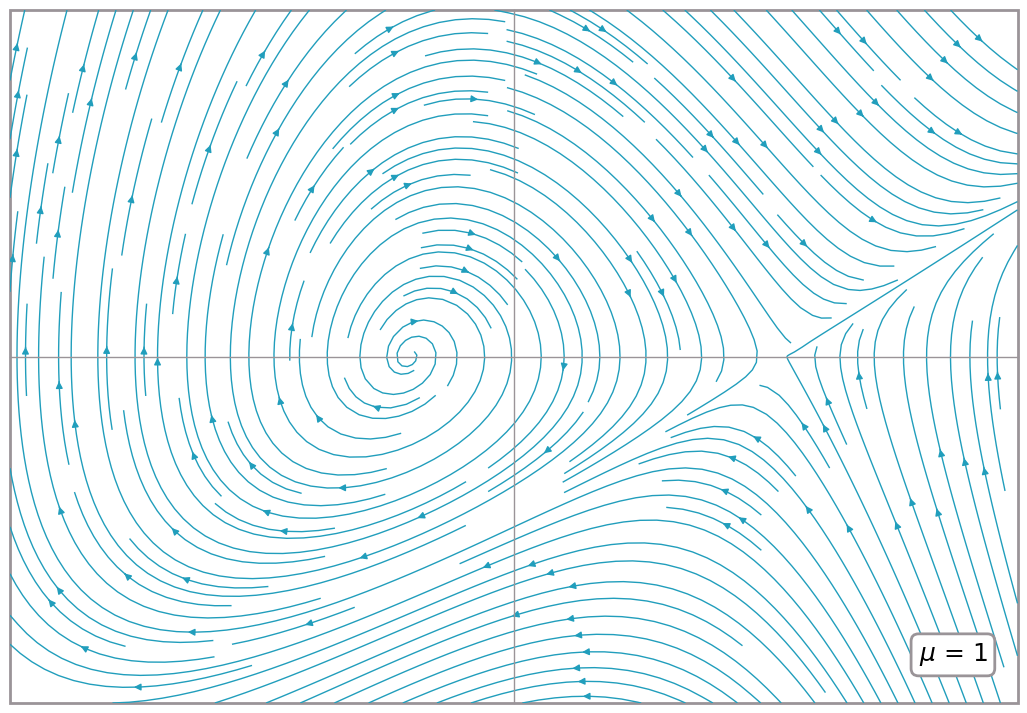

In [119]:
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)

X,Y = np.meshgrid(x, y)

mu = 1
Xdot = Y
Ydot = -mu - X + X**2 - X*Y

plt.style.use(['nature', 'vibrant'])
fig, ax = plt.subplots(1, 1, figsize=(13, 9))

ax.streamplot(X,Y, Xdot, Ydot, color = '#219ebc', linewidth = 1, broken_streamlines=True, density = 2)

ax.annotate(f'$\mu$ = {mu}', xy=(0.97, 0.05), xycoords='axes fraction', ha='right', va='bottom', fontsize=18, bbox=dict(boxstyle="round", fc="w", color = '#9A9498', lw = 2))

ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)

ax.spines['bottom'].set_color('#9A9498')
ax.spines['left'].set_color('#9A9498')

ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')

ax.tick_params(axis='both', which='major', labelsize=10, width=0.8)

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.set_xticks([ ])
ax.set_yticks([ ])

ax.patch.set_edgecolor('#9A9498')  
ax.patch.set_linewidth(2)  

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')
    
# plt.savefig(f'p1_mu{mu}.png', dpi = 400)
plt.show()

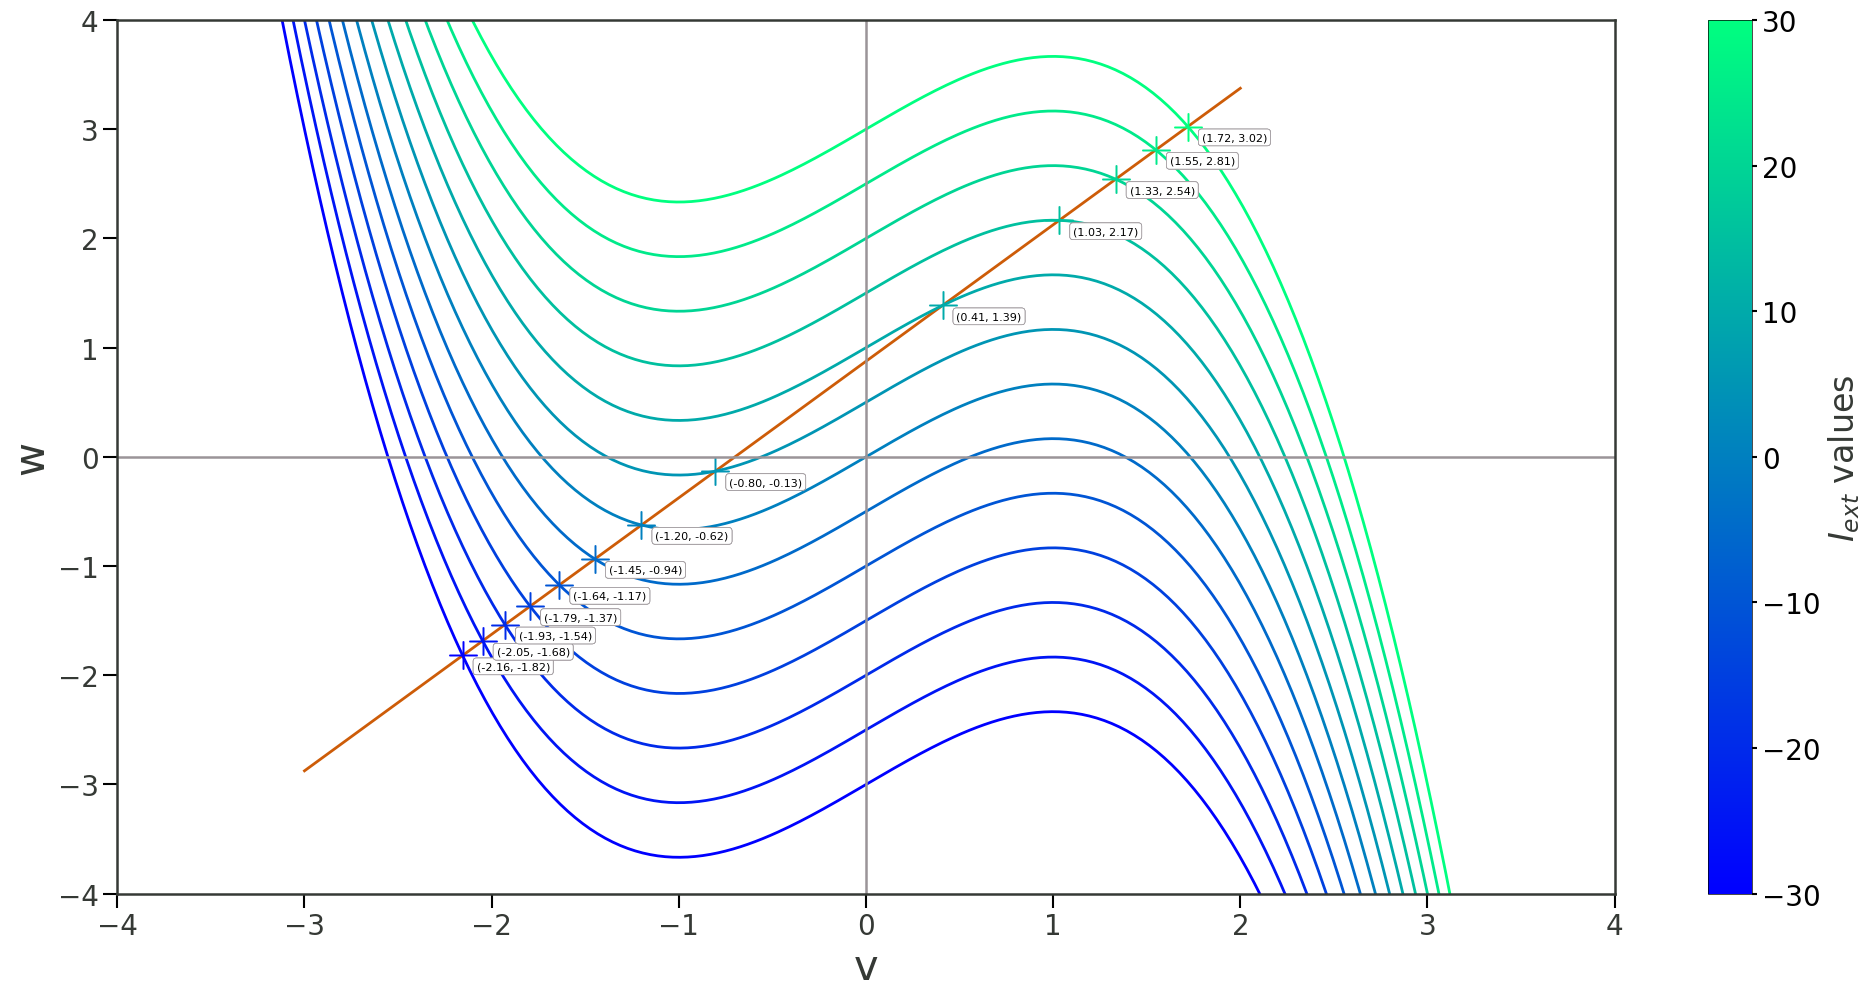

In [127]:
a = 0.7
b = 0.8
tau = 12.5
R = 0.1
def v_nullcline(v, I_ext):
    return v - v**3 / 3 + R * I_ext 

def w_nullcline(v):
    return (v + a) / b

def fixed_points(v, I_ext):
    return v - v**3 / 3 + R * I_ext - (v + a) / b

I_ext_values = np.arange(-30, 35, 5)
colors = plt.cm.winter(np.linspace(0, 1, len(I_ext_values)))  


plt.style.use(['nature', 'vibrant'])
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

ax.plot(v_vals, w_nullcline(v_vals), color='#CD5C08', linewidth=2)


for idx, I_ext in enumerate(I_ext_values):
    v_fp = fsolve(fixed_points, [-2, 0, 2], args=(I_ext)) 
    w_fp = w_nullcline(v_fp)

    v_vals = np.linspace(-4, 4, 400)
    w_v_nullcline = v_nullcline(v_vals, I_ext)
    ax.plot(v_vals, w_v_nullcline, color=colors[idx], linewidth=2)
    ax.plot(v_fp, w_fp, marker = '+', ms = 20, mec = colors[idx]) 
    for v, w in zip(v_fp, w_fp):
        ax.annotate(f"({v:.2f}, {w:.2f})", xy=(v, w), xytext=(10, -10),
                    textcoords='offset points', fontsize=8, color='black', bbox=dict(boxstyle="round", fc="w", color = '#9A9498', lw = 0.5))



sm = plt.cm.ScalarMappable(cmap='winter', norm=plt.Normalize(vmin=-30, vmax=30))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax) 
cbar.set_label("$I_{ext}$ values",fontweight='normal', fontsize=24, color = '#353935')
cbar.ax.tick_params(labelsize=20, width=1.5)

ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.spines['top'].set_linewidth(1.8)
ax.spines['right'].set_linewidth(1.8)
ax.spines['bottom'].set_color('#353935')
ax.spines['left'].set_color('#353935')
ax.spines['top'].set_color('#353935')
ax.spines['right'].set_color('#353935')
ax.tick_params(axis='both', which='major', labelsize=20, width=1.5)
ax.tick_params(axis='both', which='major', labelsize=20, width=1.5,  length=10)
ax.tick_params(axis = 'both', which='minor', width=1.5, length=3)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')
    label.set_color('#353935')

ax.set_xlabel("v", fontweight='normal', fontsize=30, color = '#353935')
ax.set_ylabel("w", fontweight='normal', fontsize=30, color = '#353935')
ax.set_xlim([v_vals.min(), v_vals.max()])
ax.set_ylim([v_vals.min(), v_vals.max()])
ax.axhline(0, color='#9A9498', linewidth=1.8)
ax.axvline(0, color='#9A9498', linewidth=1.8)

plt.tight_layout()
plt.show()


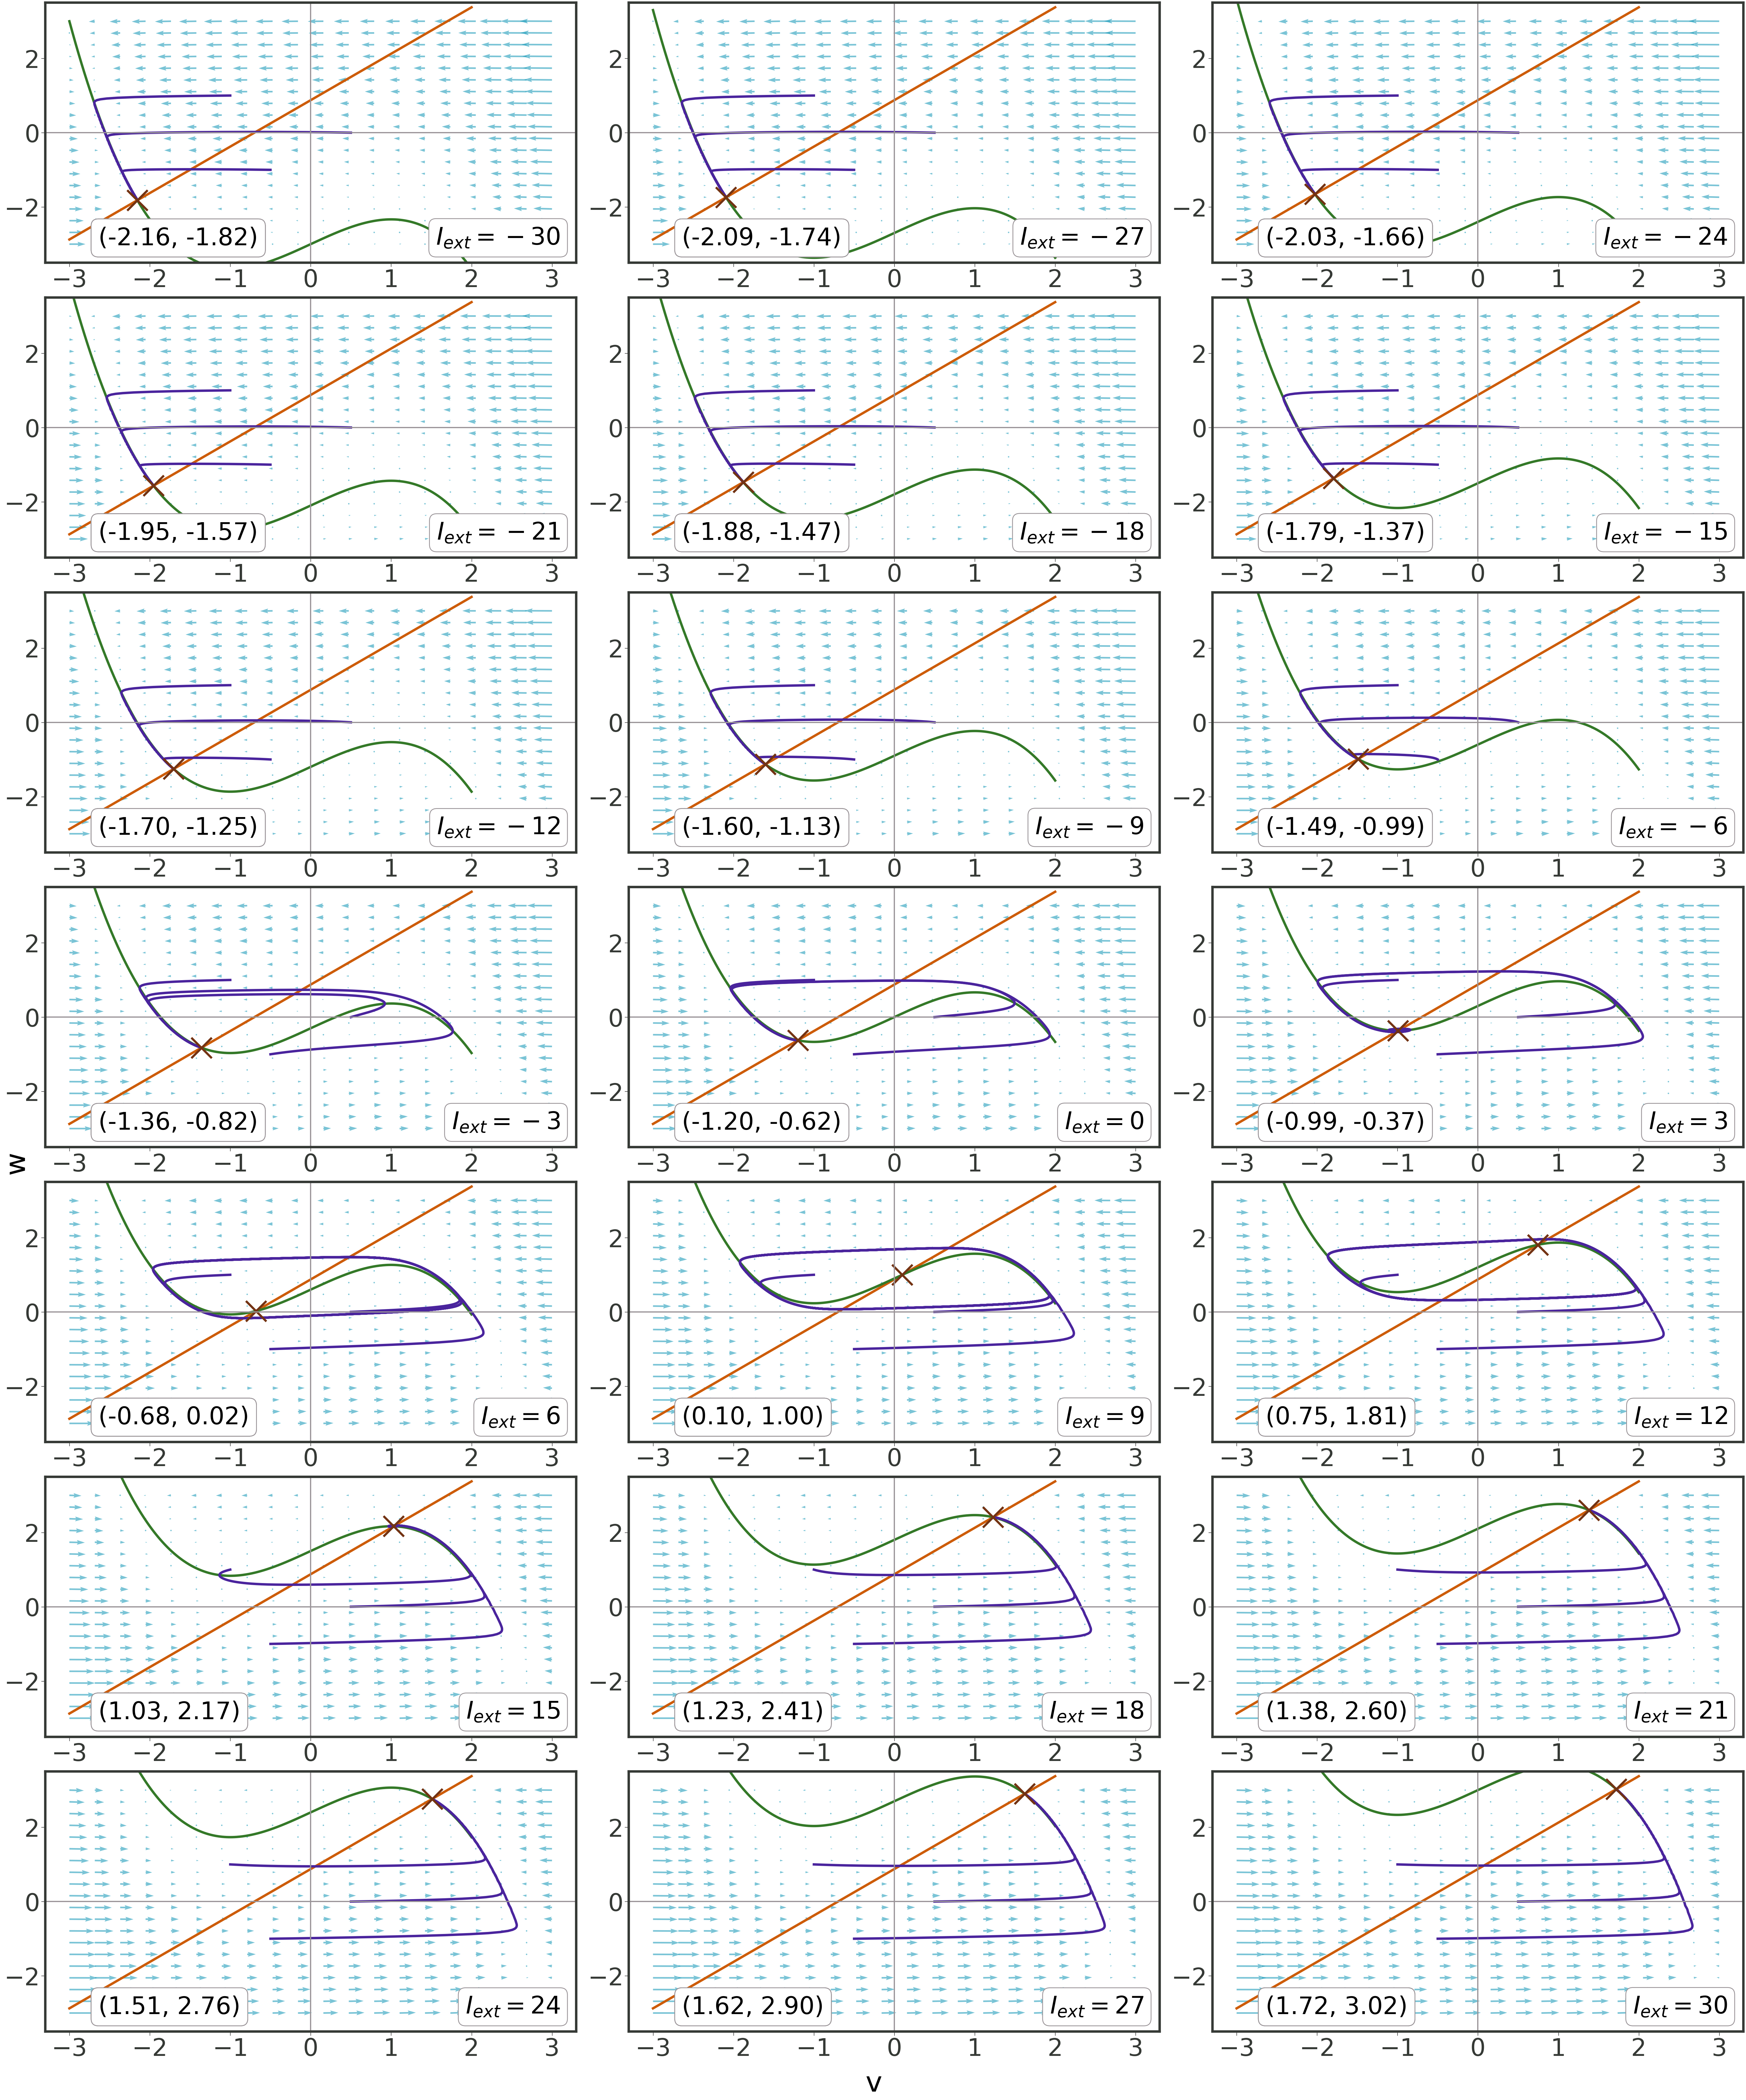

In [128]:

a = 0.7
b = 0.8
tau = 12.5
R = 0.1

def v_nullcline(v, I_ext):
    return v - v**3 / 3 + R * I_ext 

def w_nullcline(v):
    return (v + a) / b

def fixed_points(v, I_ext):
    return v - v**3 / 3 + R * I_ext - (v + a) / b

def system(t, y, I_ext):
    v, w = y
    dv_dt = v - (v**3) / 3 - w + R * I_ext
    dw_dt = (v + a - b * w) / tau
    return [dv_dt, dw_dt]

t_span = [0, 100]
t_eval = np.linspace(t_span[0], t_span[1], 1000)  
v_vals = np.linspace(-3, 2, 400)
initial_conditions = [[-1.0, 1.0], [0.5, 0.0], [-0.5, -1.0]]
I_ext_values = np.arange(-30, 33, 3) 
v_grid = np.linspace(-3, 3, 20)
w_grid = np.linspace(-3, 3, 20)
V, W = np.meshgrid(v_grid, w_grid)

fig, axes = plt.subplots(8, 3, figsize=(60, 80), constrained_layout=True)


axes = axes.flatten()

for idx, I_ext in enumerate(I_ext_values):
    if idx >= len(axes):
        break
    ax = axes[idx]
    dv_dt = V - (V**3) / 3 - W + R * I_ext
    dw_dt = (V + a - b * W) / tau
    ax.quiver(V, W, dv_dt, dw_dt, color='#219ebc', alpha=0.6, scale=30, angles='xy', scale_units='xy', headwidth = 3)
    ax.plot(v_vals, w_nullcline(v_vals), color='#CD5C08', linewidth=6)
    
    v_fp = fsolve(fixed_points, [-2, 0, 2], args=(I_ext)) 
    w_fp = w_nullcline(v_fp)

    v_vals = np.linspace(-3, 2, 400)
    w_v_nullcline = v_nullcline(v_vals, I_ext)
    ax.plot(v_vals, w_v_nullcline, color='#347928', linewidth=6)
     
    for v, w in zip(v_fp, w_fp):
        ax.annotate(f"({v:.2f}, {w:.2f})", xy=(0.1, 0.05), xycoords='axes fraction', ha='left', va='bottom',
                    textcoords='offset points', fontsize=60, color='black', bbox=dict(boxstyle="round", fc="w", color = '#9A9498', lw = 2))
    
    for ic in initial_conditions:
        sol = solve_ivp(system, t_span, ic, args=(I_ext,), t_eval=t_eval)
        ax.plot(sol.y[0], sol.y[1], color='#4A249D', linewidth=6)
        
    ax.plot(v_fp, w_fp, marker = 'x', ms = 50, mec = '#733313', mew=5)   
        
        
    ax.annotate(f"$I_{{ext}}={I_ext}$", xy=(0.97, 0.05), xycoords='axes fraction', ha='right', va='bottom', fontsize=60, bbox=dict(boxstyle="round", fc="w", color = '#9A9498', lw = 2))
#     ax.set_xlim(-2.5,2.5)
    ax.set_ylim(-3.5,3.5)
    ax.spines['bottom'].set_linewidth(6)
    ax.spines['left'].set_linewidth(6)
    ax.spines['top'].set_linewidth(6)
    ax.spines['right'].set_linewidth(6)
    ax.spines['bottom'].set_color('#353935')
    ax.spines['left'].set_color('#353935')
    ax.spines['top'].set_color('#353935')
    ax.spines['right'].set_color('#353935')
    ax.tick_params(axis='both', which='major', labelsize=60, width=1)
    ax.tick_params(axis='both', which='major', labelsize=60, width=1,  length=10)
    ax.tick_params(axis = 'both', which='minor', width=5, length=10)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('normal')
        label.set_color('#353935')

    ax.axhline(0, color='#9A9498', linewidth=3)
    ax.axvline(0, color='#9A9498', linewidth=3)
    
    
fig.text(0.5, 0.1, 'v', ha='center', fontsize=70)
fig.text(0.0, 0.5, 'w', va='center', rotation='vertical', fontsize=70)


if len(I_ext_values) < len(axes):
    for i in range(len(I_ext_values), len(axes)):
        fig.delaxes(axes[i])

# plt.savefig('q2.pdf', dpi = 400)
plt.show()

In [ ]:
a = 0.7
b = 0.8
tau = 12.5
R = 0.1

def system(t, y, I_ext):
    v, w = y
    dv_dt = v - (v**3) / 3 - w + R * I_ext
    dw_dt = (v + a - b * w) / tau
    return [dv_dt, dw_dt]

t_span = [0, 200] 
t_eval = np.linspace(t_span[0], t_span[1], 1000) 
I_ext_values = np.arange(-30, 31, 1) 

periods = []

for I_ext in I_ext_values:
    initial_condition = [0.5, 0.0]
    sol = solve_ivp(system, t_span, initial_condition, args=(I_ext,), t_eval=t_eval)
    peaks, _ = find_peaks(sol.y[0])
    
    if len(peaks) >= 2:
        period = np.mean(np.diff(sol.t[peaks]))
        periods.append(period)
    else:
        periods.append(np.nan) 



fig, ax = plt.subplots(1, 1, figsize=(13, 9))

ax.plot(I_ext_values, periods, marker = 'x', ms = 8, mec = '#0066f2', mew=0.8, linestyle='-', color = '#1d4e89', linewidth = 2)
ax.set_ylabel('Time Period $T$', fontweight='normal', fontsize=20)
ax.set_xlabel('$I_{ext}$', fontweight='normal', fontsize=20)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.spines['top'].set_linewidth(1.8)
ax.spines['right'].set_linewidth(1.8)
ax.tick_params(axis='both', which='major', labelsize=18, width=1.5)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')

plt.savefig('Tviext.png', dpi=600)
plt.show()


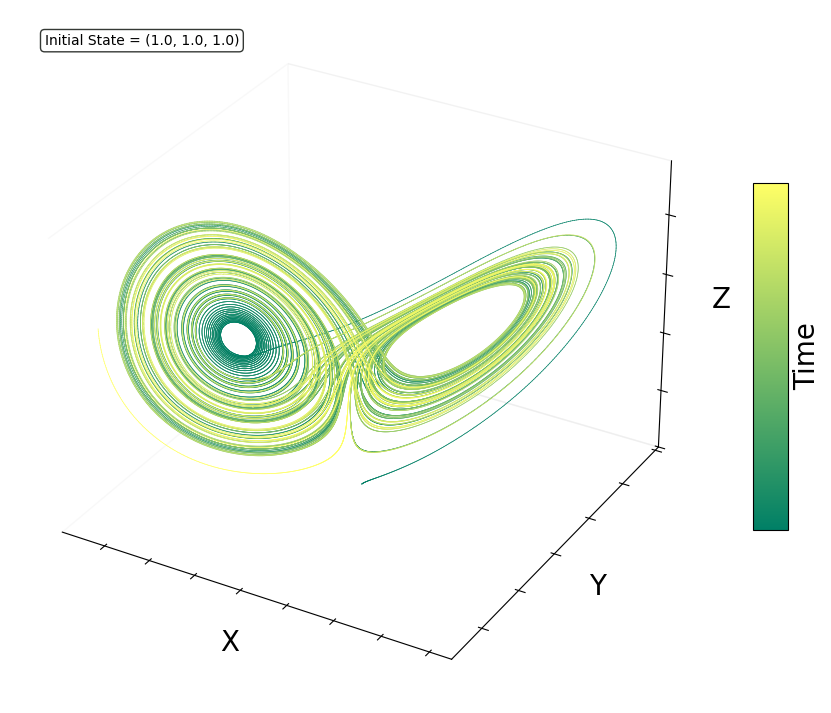

In [21]:
def lorenz(t, state, sigma, r, beta):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (r - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

sigma = 10.0
r = 28.0
beta = 8.0 / 3.0

initial_state = [1.0, 1.0, 1.0]

t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 100000)

sol = solve_ivp(lorenz, t_span, initial_state, args=(sigma, r, beta), t_eval=t_eval)

x = sol.y[0]
y = sol.y[1]
z = sol.y[2]
t = sol.t

fig = plt.figure(figsize=(13, 9))
ax = fig.add_subplot(111, projection='3d')


norm = plt.Normalize(t.min(), t.max())
colors = cm.summer(norm(t))


for i in range(len(t) - 1):
    ax.plot(x[i:i+2], y[i:i+2], z[i:i+2], color=colors[i], lw=0.5)

ax.set_xlabel('X', fontweight='normal', fontsize=20)
ax.set_ylabel('Y',fontweight='normal', fontsize=20)
ax.set_zlabel('Z',fontweight='normal', fontsize=20)

ax.text2D(0.05, 0.95, "Initial State = (1.0, 1.0, 1.0)", transform=ax.transAxes, bbox=dict(boxstyle="round", fc="w", color = '#353935', lw = 1))

ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.spines['top'].set_linewidth(1.8)
ax.spines['right'].set_linewidth(1.8)
ax.spines['bottom'].set_color('#353935')
ax.spines['left'].set_color('#353935')
ax.spines['top'].set_color('#353935')
ax.spines['right'].set_color('#353935')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.grid(False)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')
    label.set_color('#353935')


ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False


sm = plt.cm.ScalarMappable(cmap=cm.summer, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Time',fontweight='normal', fontsize=20)
cbar.set_ticks([])

plt.savefig('q3(a).png', dpi = 600)
plt.show()


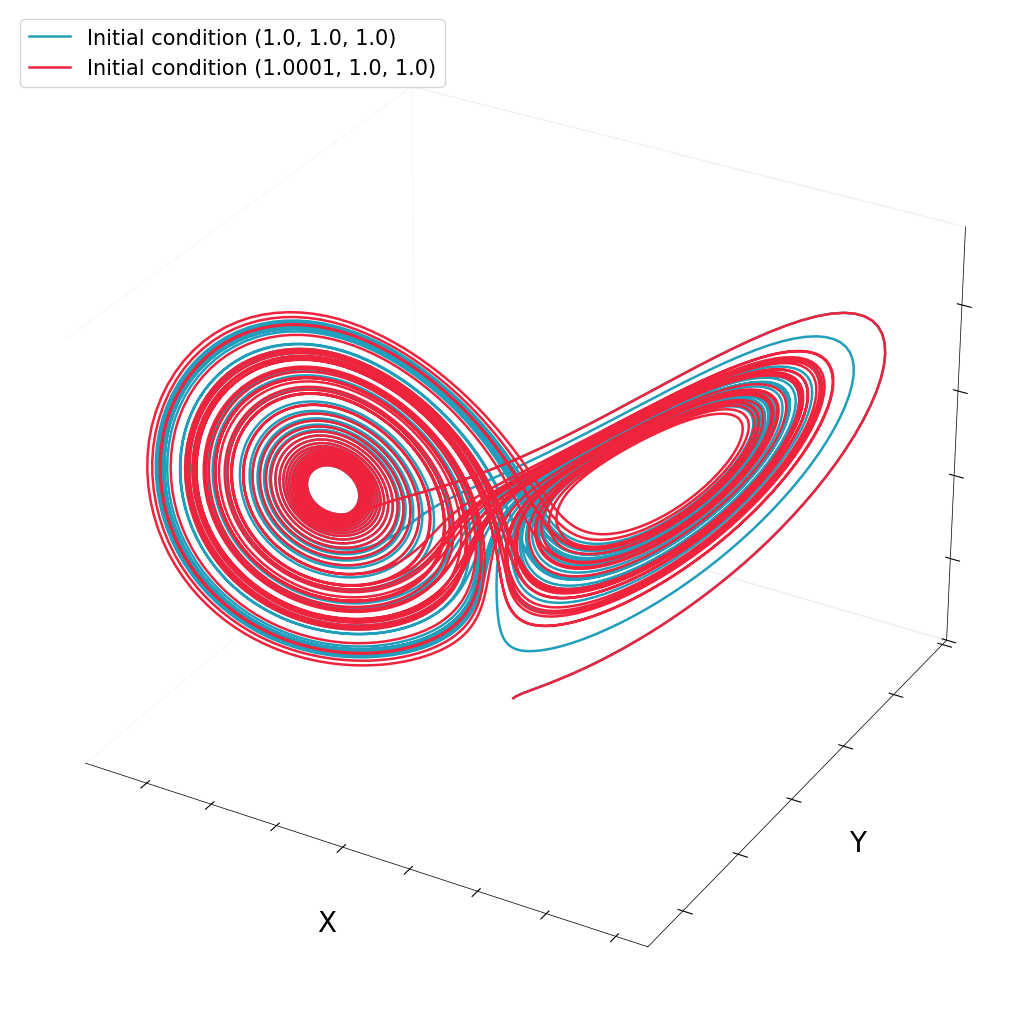

In [129]:
def lorenz(t, state, sigma, rho, beta):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0

initial_state_1 = [1.0, 1.0, 1.0]
initial_state_2 = [1.0001, 1.0, 1.0]

t_span = (0, 50) 
t_eval = np.linspace(t_span[0], t_span[1], 10000) 

sol1 = solve_ivp(lorenz, t_span, initial_state_1, args=(sigma, rho, beta), t_eval=t_eval)
sol2 = solve_ivp(lorenz, t_span, initial_state_2, args=(sigma, rho, beta), t_eval=t_eval)

x1, y1, z1 = sol1.y[0], sol1.y[1], sol1.y[2]
x2, y2, z2 = sol2.y[0], sol2.y[1], sol2.y[2]

fig = plt.figure(figsize=(13, 13))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x1, y1, z1, color = '#219ebc', linewidth = 1.8, label='Initial condition (1.0, 1.0, 1.0)')
ax.plot(x2, y2, z2, color = '#ef233c', linewidth = 1.8, label='Initial condition (1.0001, 1.0, 1.0)')

ax.set_xlabel('X', fontweight='normal', fontsize=20, labelpad=15)
ax.set_ylabel('Y', fontweight='normal', fontsize=20, labelpad=15)
ax.set_zlabel('Z', fontweight='normal', fontsize=20, labelpad=15) 

ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.spines['top'].set_linewidth(1.8)
ax.spines['right'].set_linewidth(1.8)
ax.spines['bottom'].set_color('#353935')
ax.spines['left'].set_color('#353935')
ax.spines['top'].set_color('#353935')
ax.spines['right'].set_color('#353935')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.grid(False)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')
    label.set_color('#353935')

ax.legend(fontsize=15, loc='upper left')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

plt.savefig('q3(b)plt1.pdf', dpi = 600)
plt.show()

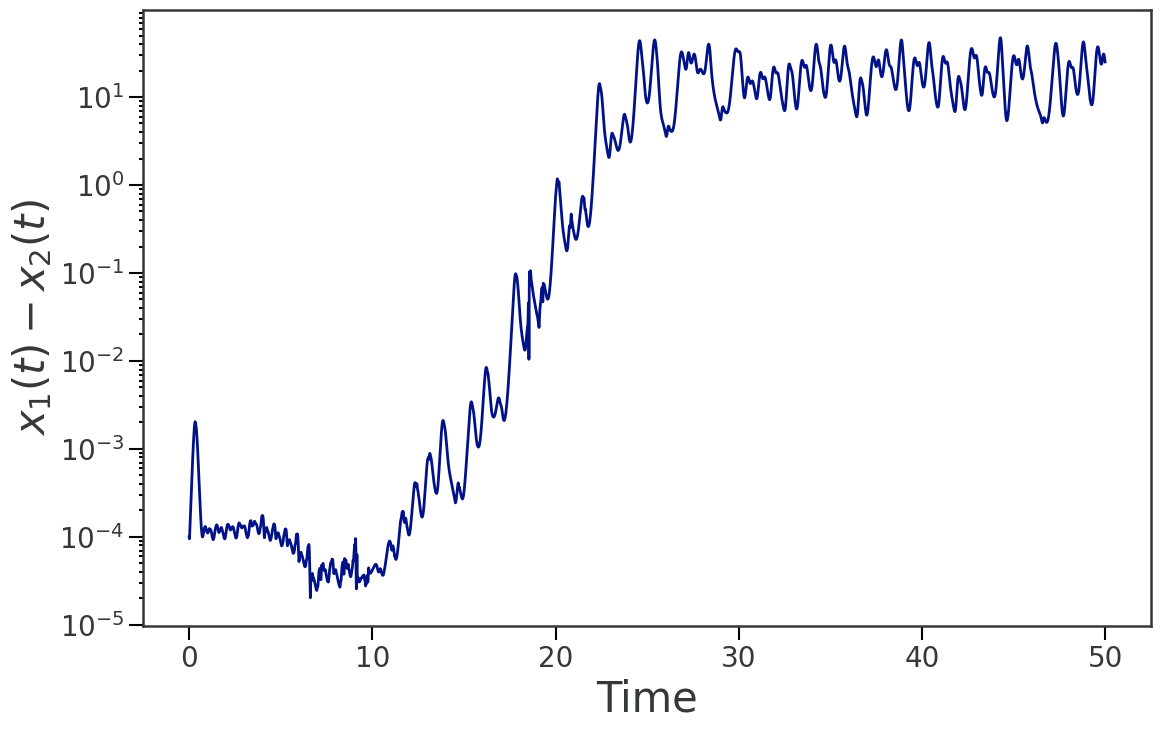

In [110]:
diff = np.sqrt((x1 - x2)**2 + (y1 - y2)**2 + (z1 - z2)**2)

fig, ax = plt.subplots(1, 1, figsize=(13, 8))
ax.plot(t_eval, diff, lw=2, color = '#011288')
ax.set_xlabel('Time', fontweight='normal', fontsize=30, color = '#353935')
ax.set_ylabel("$x_1(t) - x_2(t)$", fontweight='normal', fontsize=30, color = '#353935')
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.spines['top'].set_linewidth(1.8)
ax.spines['right'].set_linewidth(1.8)
ax.spines['bottom'].set_color('#353935')
ax.spines['left'].set_color('#353935')
ax.spines['top'].set_color('#353935')
ax.spines['right'].set_color('#353935')
ax.tick_params(axis='both', which='major', labelsize=20, width=1.5,  length=10)
ax.tick_params(axis = 'both', which='minor', width=1.5, length=3)
ax.set_yscale('log')
# ax.set_ylim(1e-5, 1e3)
ax.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=10))
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')
    label.set_color('#353935')
    
plt.savefig('q3_diff.png', dpi = 600)
plt.show()

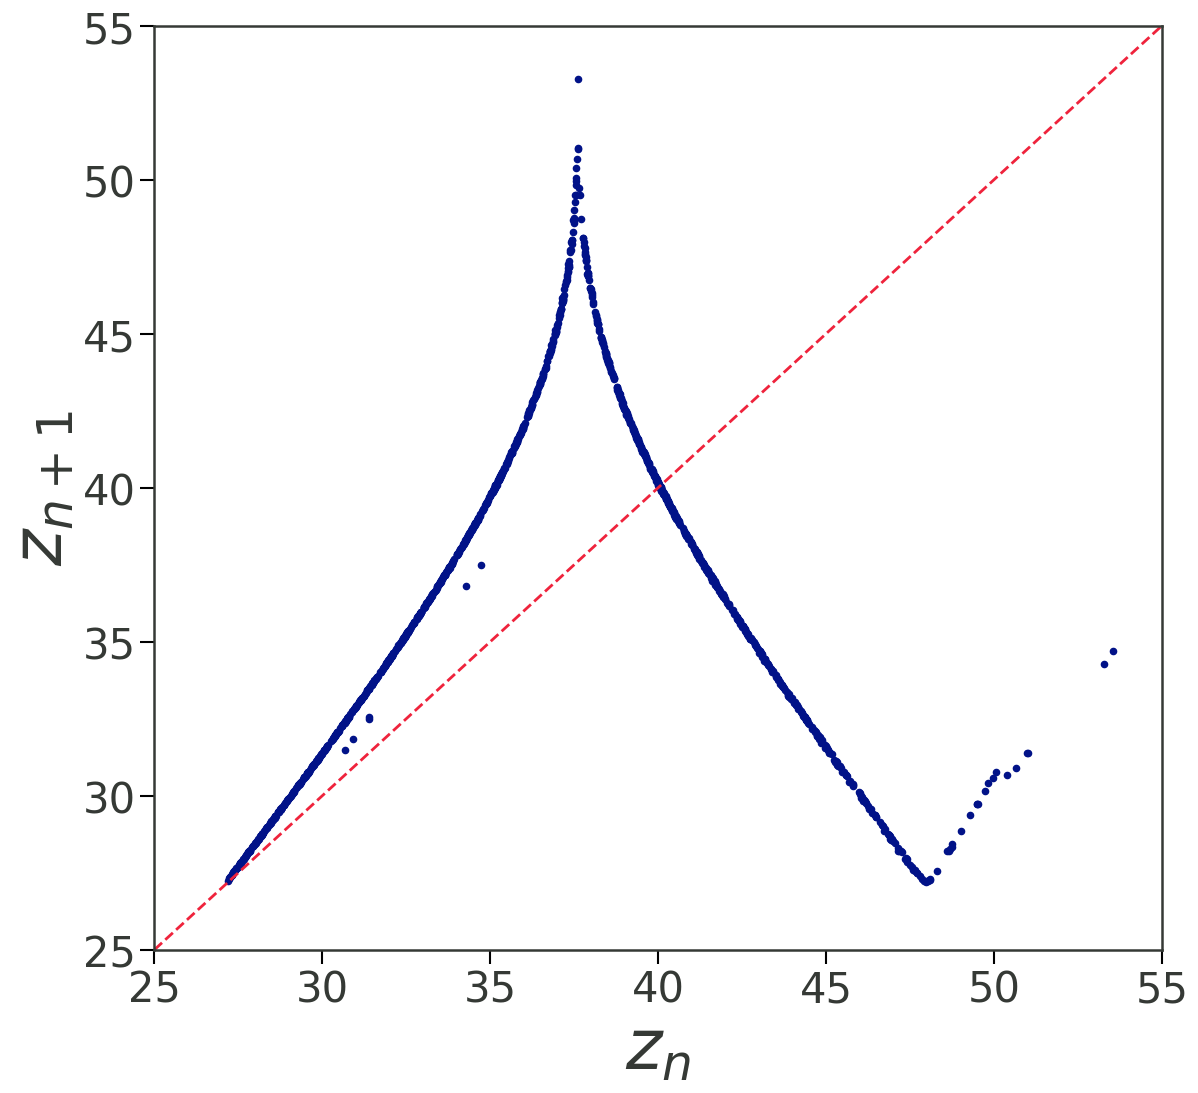

In [146]:
sigma = 10
b = 8/3
r = 28

def lorenz_system(dt, steps, initial_conditions):
    x, y, z = initial_conditions
    trajectory = []
    for _ in range(steps):
        dx = sigma * (y - x) * dt
        dy = (x * (r - z) - y) * dt
        dz = (x * y - b * z) * dt
        x += dx
        y += dy
        z += dz
        trajectory.append((x, y, z))
    return np.array(trajectory)

dt = 0.01
steps = 100000
initial_conditions = (1.0, 1.0, 1.0)
trajectory = lorenz_system(dt, steps, initial_conditions)

z_values = trajectory[:, 2]

local_max_indices = argrelextrema(z_values, np.greater)[0]
local_maxima = z_values[local_max_indices]

z_return_map = local_maxima[:-1]  
z_next = local_maxima[1:]


fig, ax = plt.subplots(1, 1, figsize=(13, 12))
ax.scatter(z_return_map, z_next, s=20, color = '#011288')
ax.axline((0, 0), slope=1, color='#ef233c', linestyle='--', label='y = x', lw = 2)
ax.set_xlabel(r'$z_n$', fontweight='normal', fontsize=50, color = '#353935')
ax.set_ylabel(r'$z_{n+1}$', fontweight='normal', fontsize=50, color = '#353935')
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.spines['top'].set_linewidth(1.8)
ax.spines['right'].set_linewidth(1.8)
ax.spines['bottom'].set_color('#353935')
ax.spines['left'].set_color('#353935')
ax.spines['top'].set_color('#353935')
ax.spines['right'].set_color('#353935')
ax.tick_params(axis='both', which='major', labelsize=30, width=1.5,  length=10)
ax.tick_params(axis = 'both', which='minor', width=1.5, length=3)

ax.set_xlim(25, 55)
ax.set_ylim(25, 55)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('normal')
    label.set_color('#353935')
    
plt.savefig('q3_(c).pdf', dpi = 600)
plt.show()

In [149]:

sigma = 10
b = 8/3
r = 28

def lorenz_system(dt, steps, initial_conditions):
    x, y, z = initial_conditions
    trajectory = []
    for _ in range(steps):
        dx = sigma * (y - x) * dt
        dy = (x * (r - z) - y) * dt
        dz = (x * y - b * z) * dt
        x += dx
        y += dy
        z += dz
        trajectory.append((x, y, z))
    return np.array(trajectory)

dt = 0.01
steps = 10000
initial_conditions = (1.0, 1.0, 1.0)
trajectory = lorenz_system(dt, steps, initial_conditions)

z_values = trajectory[:, 2]

local_max_indices = argrelextrema(z_values, np.greater)[0]
local_maxima = z_values[local_max_indices]

z_return_map = local_maxima[:-1]
z_next = local_maxima[1:]

return_map_func = interp1d(z_return_map, z_next, kind='cubic', fill_value="extrapolate")

def fixed_point_function(z):
    return return_map_func(z) - z

initial_guess = np.mean(local_maxima)
fixed_point = fsolve(fixed_point_function, initial_guess)[0]

print(f"Numerically determined fixed point z̄: {fixed_point:.4f}")

def derivative_at_fixed_point(z):
    h = 1e-5
    return (return_map_func(z + h) - return_map_func(z - h)) / (2 * h)

slope_at_fixed_point = derivative_at_fixed_point(fixed_point)
print(f"Slope at fixed point (P'(z̄)): {slope_at_fixed_point:.4f}")

if abs(slope_at_fixed_point) > 1:
    print("An unstable periodic orbit exists at z̄, because |P'(z̄)| > 1.")
else:
    print("The periodic orbit is stable, because |P'(z̄)| <= 1.")

Numerically determined fixed point z̄: 27.4485
Slope at fixed point (P'(z̄)): 2.0125
An unstable periodic orbit exists at z̄, because |P'(z̄)| > 1.
